# Lab — Time Series Analysis with the UCI Bike Sharing Dataset

**Module:** Time Series Analysis and Forecasting  
**Estimated Time:** 90–120 minutes  
**Dataset:** UCI Bike Sharing Dataset, `day.csv`  
**Primary Skills:** datetime handling, time series data quality, resampling, rolling averages, seasonality analysis, baseline forecasting, forecast evaluation

---

## Lab Scenario

You are a data analyst for a bike sharing company.

Your manager wants to understand how bike rental demand changes over time and whether simple baseline forecasts can provide a useful starting point for short-term demand planning.

Before building any advanced forecasting model, your job is to complete a practical time series workflow:

1. Load and inspect the dataset.
2. Convert the date column into a proper datetime format.
3. Sort and index the data chronologically.
4. Check whether the time series has missing dates or duplicate timestamps.
5. Explore trend, seasonality, and rolling averages.
6. Build simple baseline forecasts.
7. Evaluate the forecasts with MAE and RMSE.
8. Communicate your findings clearly.

This lab is intentionally focused on workflow and interpretation, not advanced forecasting models.

---

## Dataset Overview

You will use the **UCI Bike Sharing Dataset**.

For this lab, use the file:

```text
day.csv
```

Each row represents one day of bike rental activity.

### Important Columns

| Column | Description |
|---|---|
| `instant` | Record index |
| `dteday` | Date |
| `season` | Season encoded as a number |
| `yr` | Year encoded as `0` or `1` |
| `mnth` | Month number |
| `holiday` | Whether the day was a holiday |
| `weekday` | Day of the week |
| `workingday` | Whether the day was a working day |
| `weathersit` | Weather situation category |
| `temp` | Normalized temperature |
| `atemp` | Normalized feeling temperature |
| `hum` | Normalized humidity |
| `windspeed` | Normalized wind speed |
| `casual` | Count of casual users |
| `registered` | Count of registered users |
| `cnt` | Total rental bike count |

For this lab, your main target column is:

```python
cnt
```

This represents total bike rentals for the day.

---

## Lab Learning Objectives

By the end of this lab, you will be able to:

- Load a real time series dataset into pandas.
- Convert a date column using `pd.to_datetime()`.
- Sort a dataset chronologically.
- Set a datetime column as the DataFrame index.
- Check for duplicate timestamps.
- Check for missing dates in a daily time series.
- Resample daily data into weekly and monthly summaries.
- Use rolling averages to smooth noisy daily data.
- Analyze trend and seasonality.
- Create simple baseline forecasts.
- Evaluate forecasts using MAE and RMSE.
- Explain the limitations of baseline forecasting.

---

---

## Part 1 — Load the Dataset

### Option A: Load from a Local CSV File

Use this option if `day.csv` is already saved in your project folder.

```python
bike = pd.read_csv("day.csv")
```

### Option B: Load Directly from a URL

Use this option if your instructor gives you a direct raw CSV URL.

```python
url = "YOUR_RAW_CSV_URL_HERE"
bike = pd.read_csv(url)
```


In [47]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [48]:
df = pd.read_csv("../data/raw/day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [49]:
# Q1: How many rows?
print(f"Number of rows: {len(df)}")
print(f"Shape: {df.shape}")

Number of rows: 731
Shape: (731, 16)


In [50]:
# Check column info
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nIs 'dteday' a datetime?", df['dteday'].dtype)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Data types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Is 'dteday' a datetime? object


---
### Questions

Answer these in a markdown cell:

1. How many rows are in the dataset?
2. What does one row represent?
3. Which column contains the date?
4. Which column contains the total number of rentals?
5. Is the date column already stored as a datetime type?


## Answers

1. **How many rows are in the dataset?** The dataset has 731 rows.

2. **What does one row represent?** Each row represents one day of bike rental activity, including the date, weather conditions, user counts, and rental totals for that day.

3. **Which column contains the date?** The dteday column contains the date.

4. **Which column contains the total number of rentals?** The cnt column contains the total number of bike rentals.

5. **Is the date column already stored as a datetime type?** No, the dteday column is stored as an object (string) type, not as a datetime type. We need to convert it using pd.to_datetime() for proper time series analysis.

---

## Part 2 — Create a Proper Datetime Index

The column `dteday` contains the date, but pandas may initially read it as text.

### Tasks:

1. Convert `dteday` to Datetime

2. Sort by Date

3. Set the Date as the Index

### Questions

Answer these in a markdown cell:

1. Why do we convert `dteday` with `pd.to_datetime()`?
2. Why should time series data be sorted before analysis?
3. What changed after setting `dteday` as the index?


In [51]:
# Convert dteday to datetime
df['dteday'] = pd.to_datetime(df['dteday'])
print(f"Data type of dteday: {df['dteday'].dtype}")
print(df['dteday'].head())

Data type of dteday: datetime64[ns]
0   2011-01-01
1   2011-01-02
2   2011-01-03
3   2011-01-04
4   2011-01-05
Name: dteday, dtype: datetime64[ns]


In [52]:
# Sort by date
df = df.sort_values('dteday')
print("First few rows after sorting:")
print(df[['dteday', 'cnt']].head())
print("\nLast few rows after sorting:")
print(df[['dteday', 'cnt']].tail())

First few rows after sorting:
      dteday   cnt
0 2011-01-01   985
1 2011-01-02   801
2 2011-01-03  1349
3 2011-01-04  1562
4 2011-01-05  1600

Last few rows after sorting:
        dteday   cnt
726 2012-12-27  2114
727 2012-12-28  3095
728 2012-12-29  1341
729 2012-12-30  1796
730 2012-12-31  2729


In [53]:
# Set dteday as the index (if not already)
if 'dteday' in df.columns:
    df = df.set_index('dteday')
print("New index:")
print(df.index)
print("\nDataFrame with datetime index:")
print(df.head())

New index:
DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2012-12-22', '2012-12-23', '2012-12-24', '2012-12-25',
               '2012-12-26', '2012-12-27', '2012-12-28', '2012-12-29',
               '2012-12-30', '2012-12-31'],
              dtype='datetime64[ns]', name='dteday', length=731, freq=None)

DataFrame with datetime index:
            instant  season  yr  mnth  holiday  weekday  workingday  \
dteday                                                                
2011-01-01        1       1   0     1        0        6           0   
2011-01-02        2       1   0     1        0        0           0   
2011-01-03        3       1   0     1        0        1           1   
2011-01-04        4       1   0     1        0        2           1   
2011-01-05        5       1   0     1        0        3          

## Answers

1. **Why do we convert `dteday` with `pd.to_datetime()`?**
   - Converting to datetime enables pandas to recognize dates as temporal objects rather than text strings. This allows us to perform date-based operations (sorting, filtering by date range etc.) It's essential for proper time series analysis.

2. **Why should time series data be sorted before analysis?**
   - Sorting by date ensures the data is in chronological order, which is required for meaningful time series analysis. Many time series operations like rolling averages depend on the data being sequentially ordered. Unsorted data would produce incorrect results for trend analysis, seasonality detection, and modeling.

3. **What changed after setting `dteday` as the index?**
   - After setting the date as the index, the DataFrame now has a DatetimeIndex instead of a numeric integer index. This allows us to access rows by date using `.loc[]` with date values, enables time-based slicing (e.g., `df['2011-06':'2011-08']`), and supports pandas' time series functionality like resampling, rolling operations, and frequency inference. The date becomes the primary way to reference each row.

---

## Part 3 — Time Series Data Quality Checks

Before analyzing a time series, check whether the time index is complete, unique, sorted, and regular.

### Tasks 

1. Check for Duplicate Timestamps
2. Check Whether the Index Is Sorted
3. Infer the Frequency
4. Check for Missing Dates

### Questions

Answer these in a markdown cell:

1. Are there duplicate dates?
2. Is the index sorted chronologically?
3. Does pandas detect a daily frequency?
4. Are any dates missing?
5. Why are missing timestamps different from missing values?


In [54]:
# Task 1: Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print(f"Number of duplicate dates: {duplicates}")

Number of duplicate dates: 0


In [55]:
# Task 2: Check whether the index is sorted
is_sorted = df.index.is_monotonic_increasing
print(f"Is the index sorted chronologically? {is_sorted}")

Is the index sorted chronologically? True


In [56]:
# Task 3: Infer the frequency
inferred_freq = pd.infer_freq(df.index)
print(f"Inferred frequency: {inferred_freq}")

Inferred frequency: D


In [57]:
# Task 4: Check for missing dates
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = full_date_range.difference(df.index)
print(f"Number of missing dates: {len(missing_dates)}")
if len(missing_dates) > 0:
    print("Missing dates:", missing_dates)
else:
    print("No missing dates — the time series is complete.")

Number of missing dates: 0
No missing dates — the time series is complete.


## Answers

1. **Are there duplicate dates?** No, there are 0 duplicate dates. Each date appears exactly once in the index.

2. **Is the index sorted chronologically?** Yes — `is_monotonic_increasing` returns `True`, confirming the data runs from earliest to latest date.

3. **Does pandas detect a daily frequency?** Yes — `pd.infer_freq()` returns `'D'`, confirming pandas recognizes a regular daily frequency.

4. **Are any dates missing?** No dates are missing. The dataset spans continuously from 2011-01-01 to 2012-12-31 with all 731 days present.

5. **Why are missing timestamps different from missing values?** A missing value (NaN) means a row exists for that date but the measurement is absent. A missing timestamp means the entire row is absent — there is no entry at all. Missing timestamps can silently corrupt rolling windows, lag calculations, and resampling because pandas assumes the index is continuous.

## Part 4 — Initial Time Series Visualization

### Tasks 

1. Plot Daily Bike Rentals

### Questions

Answer these in a markdown cell:

1. Does bike rental demand appear to change over time?
2. Do you notice any repeating patterns?
3. Does the data look noisy at the daily level?
4. Are there any sudden drops or spikes worth investigating?

---

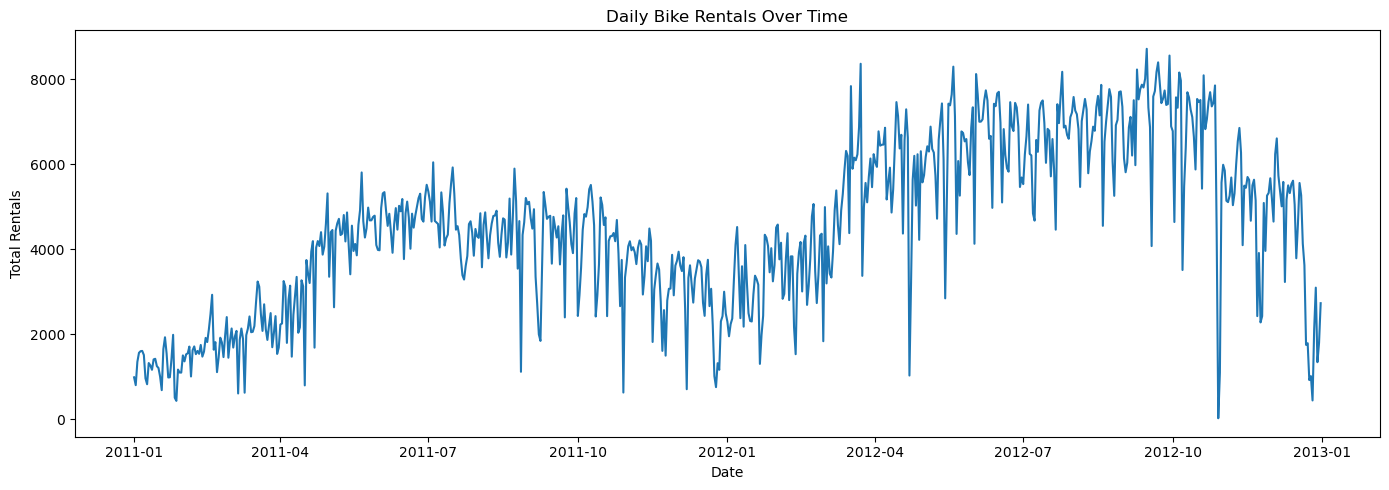

In [58]:
# Task 1: Plot daily bike rentals
plt.figure(figsize=(14, 5))
sns.lineplot(x=df.index, y=df["cnt"])
plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.show()

## Answers

1. **Does bike rental demand appear to change over time?** Yes — there is a visible upward trend. Rentals in 2012 are generally higher than in 2011, suggesting growing demand for the bike share service.

2. **Do you notice any repeating patterns?** Yes — rentals appear to peak mid-year (summer months) and dip in the winter months each year, suggesting a clear annual seasonal cycle.

3. **Does the data look noisy at the daily level?** Yes — there is substantial day-to-day variation, with sharp spikes and dips that make the underlying trend difficult to see without smoothing.

4. **Are there any sudden drops or spikes worth investigating?** Yes — there are several isolated very low-count days visible as sharp dips, which likely correspond to holidays, severe weather events, or maintenance periods.

## Part 5 — Resampling Daily Data

Daily data can be noisy. Resampling helps summarize the data at a different time level.

### Tasks 

1. Weekly Total Rentals
2. Monthly Total Rentals
3. Monthly Average Daily Rentals

### Questions

Answer these in a markdown cell:

1. What question does weekly total rentals answer?
2. What question does monthly total rentals answer?
3. What question does monthly average daily rentals answer?
4. How does resampling change what you can see in the data?
5. Which version is easier to interpret: daily, weekly, or monthly? Why?

---

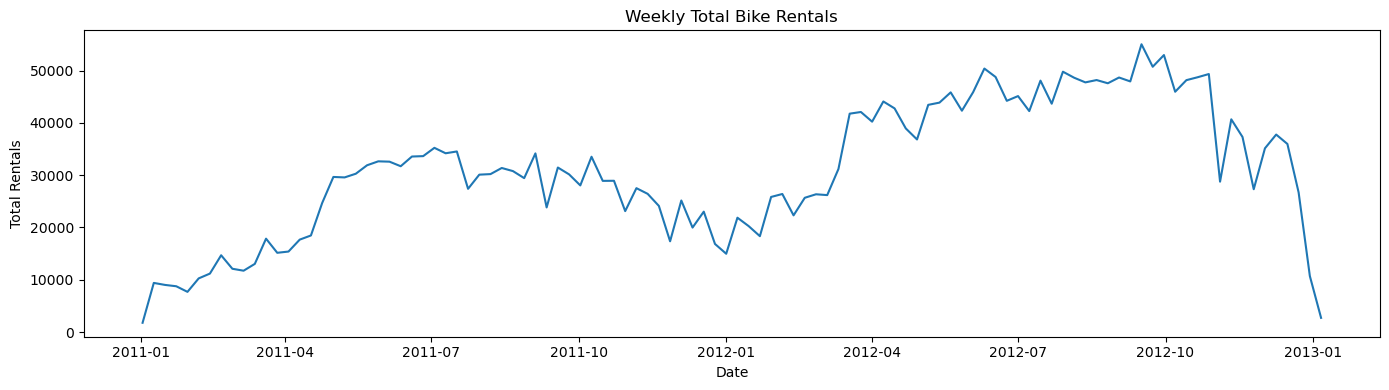

dteday
2011-01-02    1786
2011-01-09    9408
2011-01-16    9025
2011-01-23    8770
2011-01-30    7699
Freq: W-SUN, Name: cnt, dtype: int64

In [59]:
#  Weekly total rentals
weekly_totals = df["cnt"].resample("W").sum()

plt.figure(figsize=(14, 4))
sns.lineplot(x=weekly_totals.index, y=weekly_totals.values)
plt.title("Weekly Total Bike Rentals")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.show()

weekly_totals.head()

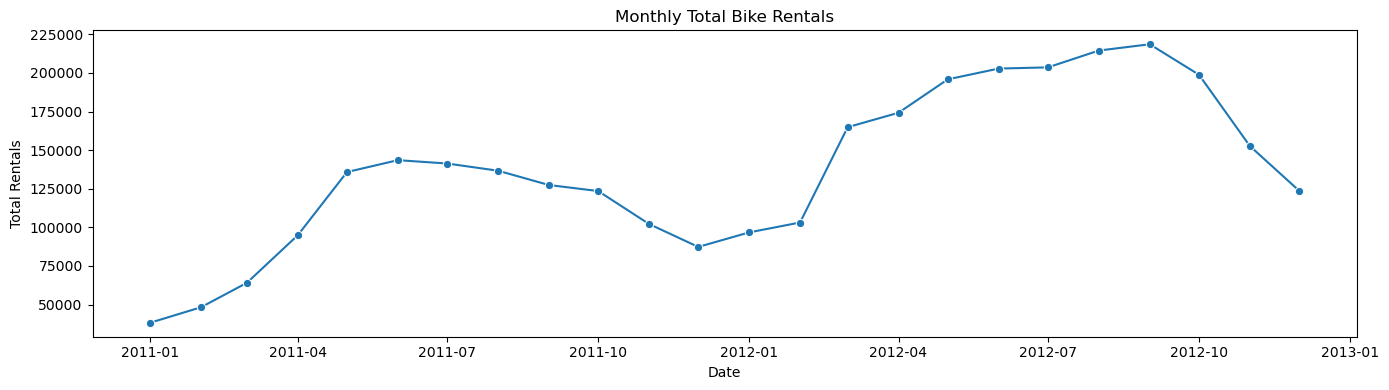

dteday
2011-01-01     38189
2011-02-01     48215
2011-03-01     64045
2011-04-01     94870
2011-05-01    135821
2011-06-01    143512
2011-07-01    141341
2011-08-01    136691
2011-09-01    127418
2011-10-01    123511
2011-11-01    102167
2011-12-01     87323
2012-01-01     96744
2012-02-01    103137
2012-03-01    164875
2012-04-01    174224
2012-05-01    195865
2012-06-01    202830
2012-07-01    203607
2012-08-01    214503
2012-09-01    218573
2012-10-01    198841
2012-11-01    152664
2012-12-01    123713
Freq: MS, Name: cnt, dtype: int64

In [60]:
#  Monthly total rentals
monthly_totals = df["cnt"].resample("MS").sum()

plt.figure(figsize=(14, 4))
sns.lineplot(x=monthly_totals.index, y=monthly_totals.values, marker="o")
plt.title("Monthly Total Bike Rentals")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.show()

monthly_totals

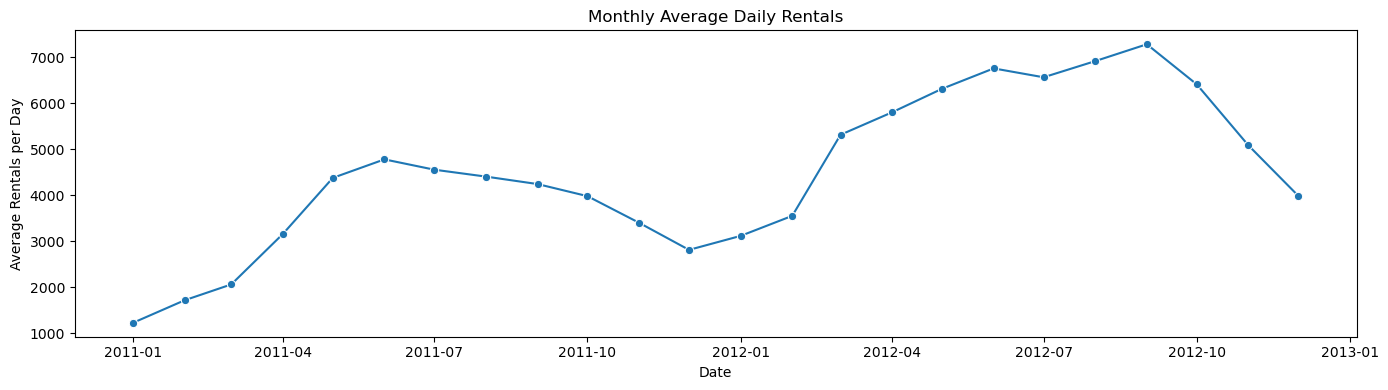

dteday
2011-01-01    1231.903226
2011-02-01    1721.964286
2011-03-01    2065.967742
2011-04-01    3162.333333
2011-05-01    4381.322581
2011-06-01    4783.733333
2011-07-01    4559.387097
2011-08-01    4409.387097
2011-09-01    4247.266667
2011-10-01    3984.225806
2011-11-01    3405.566667
2011-12-01    2816.870968
2012-01-01    3120.774194
2012-02-01    3556.448276
2012-03-01    5318.548387
2012-04-01    5807.466667
2012-05-01    6318.225806
2012-06-01    6761.000000
2012-07-01    6567.967742
2012-08-01    6919.451613
2012-09-01    7285.766667
2012-10-01    6414.225806
2012-11-01    5088.800000
2012-12-01    3990.741935
Freq: MS, Name: cnt, dtype: float64

In [61]:
# Monthly average daily rentals
monthly_avg = df["cnt"].resample("MS").mean()

plt.figure(figsize=(14, 4))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker="o")
plt.title("Monthly Average Daily Rentals")
plt.xlabel("Date")
plt.ylabel("Average Rentals per Day")
plt.tight_layout()
plt.show()

monthly_avg

## Answers

1. **What question does weekly total rentals answer?** "How many bikes were rented in total during each week?" It captures week-by-week business volume and smooths out day-of-week variation.

2. **What question does monthly total rentals answer?** "How many bikes were rented across the entire month?" This is useful for monthly planning, revenue tracking, and comparing business scale across months and years.

3. **What question does monthly average daily rentals answer?** "On a typical day within each month, how many bikes were rented?" This controls for months having different numbers of days, making month-to-month comparisons fairer.

4. **How does resampling change what you can see in the data?** Resampling removes short-term noise, making the seasonal arc and overall upward trend much clearer. The trade-off is that individual-day variation and detail are lost.

5. **Which version is easier to interpret: daily, weekly, or monthly? Why?** Monthly is generally easiest to interpret because it eliminates both day-of-week and week-to-week noise while clearly showing the annual seasonal pattern. Daily is informative but visually overwhelming.

---
## Part 6 — Rolling Averages

Rolling averages help smooth short-term fluctuations.

### Tasks 

1. Create Rolling Average Columns for 7 and 30 days
2. Plot Daily Rentals with Rolling Averages

### Questions

Answer these in a markdown cell:

1. What does the 7-day rolling average smooth out?
2. What does the 30-day rolling average reveal?
3. Which line is most useful for seeing short-term changes?
4. Which line is most useful for seeing the larger trend?
5. Why do the first few rolling average values appear as missing?

---

In [62]:
#  Create rolling average columns
df["rolling_7"] = df["cnt"].rolling(window=7).mean()
df["rolling_30"] = df["cnt"].rolling(window=30).mean()

df[["cnt", "rolling_7", "rolling_30"]].head(35)

,cnt,rolling_7,rolling_30
dteday,,,
2011-01-01,985,NaN,NaN
2011-01-02,801,NaN,NaN
2011-01-03,1349,NaN,NaN
2011-01-04,1562,NaN,NaN
2011-01-05,1600,NaN,NaN
2011-01-06,1606,NaN,NaN
2011-01-07,1510,1344.714286,NaN
2011-01-08,959,1341.000000,NaN
2011-01-09,822,1344.000000,NaN


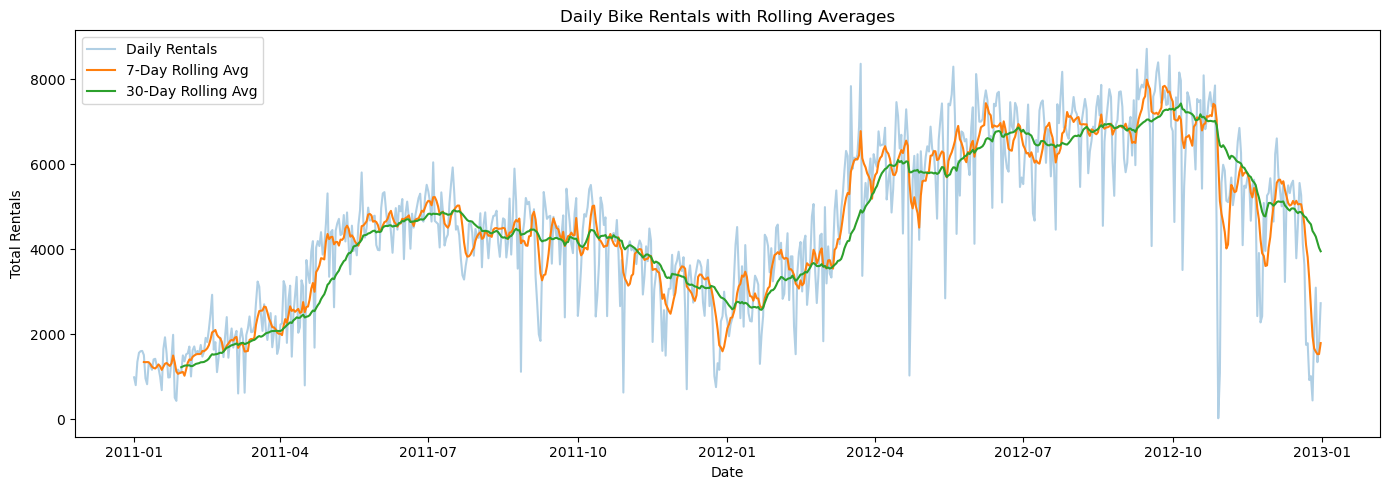

In [63]:
# Plot daily rentals with rolling averages
plt.figure(figsize=(14, 5))
sns.lineplot(x=df.index, y=df["cnt"], alpha=0.35, label="Daily Rentals")
sns.lineplot(x=df.index, y=df["rolling_7"], label="7-Day Rolling Avg")
sns.lineplot(x=df.index, y=df["rolling_30"], label="30-Day Rolling Avg")
plt.title("Daily Bike Rentals with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.tight_layout()
plt.show()

## Answers

1. **What does the 7-day rolling average smooth out?** It smooths day-of-week fluctuations — the regular spikes and dips tied to weekday/weekend patterns — while still tracking changes that occur week-to-week.

2. **What does the 30-day rolling average reveal?** It reveals the broader seasonal trend: the gradual build-up in spring, the summer peak, and the decline into winter. Nearly all short-term noise is removed.

3. **Which line is most useful for seeing short-term changes?** The 7-day rolling average — it responds more quickly to recent changes while still providing some smoothing.

4. **Which line is most useful for seeing the larger trend?** The 30-day rolling average clearly shows the multi-month seasonal arc and the overall upward shift from 2011 to 2012.

5. **Why do the first few rolling average values appear as missing?** A rolling window of N days requires N data points before it can compute a mean. The 7-day window produces NaN for the first 6 rows and the 30-day window for the first 29 rows, because there is not yet enough history to fill the window.

---

## Part 7 — Date Part Features

Extracting date parts helps us analyze calendar-based patterns.

### Tasks 

1. Create Date Part Columns (Year, Month, Day, etc.)



In [64]:
# Task 1: Create date part columns
bike_ts = df.copy()
bike_ts["year"] = bike_ts.index.year
bike_ts["month"] = bike_ts.index.month
bike_ts["day_of_week"] = bike_ts.index.dayofweek          # 0 = Monday, 6 = Sunday
bike_ts["day_name"] = bike_ts.index.day_name()
bike_ts["week_of_year"] = bike_ts.index.isocalendar().week.astype(int)
bike_ts["quarter"] = bike_ts.index.quarter

bike_ts[["cnt", "year", "month", "day_of_week", "day_name", "week_of_year", "quarter"]].head(10)

,cnt,year,month,day_of_week,day_name,week_of_year,quarter
dteday,,,,,,,
2011-01-01,985,2011,1,5,Saturday,52,1
2011-01-02,801,2011,1,6,Sunday,52,1
2011-01-03,1349,2011,1,0,Monday,1,1
2011-01-04,1562,2011,1,1,Tuesday,1,1
2011-01-05,1600,2011,1,2,Wednesday,1,1
2011-01-06,1606,2011,1,3,Thursday,1,1
2011-01-07,1510,2011,1,4,Friday,1,1
2011-01-08,959,2011,1,5,Saturday,1,1
2011-01-09,822,2011,1,6,Sunday,1,1


---

## Part 8 — Analyze Seasonality

### Tasks 

1. Average Rentals by Month
2. Average Rentals by Day of Week
3. Compare Rentals by Season

### Questions

Answer these in a markdown cell:

1. Which months have the highest average rentals?
2. Which months have the lowest average rentals?
3. Are rentals higher on weekdays or weekends?
4. Which season has the highest rental counts?
5. What seasonal patterns do you notice?

---

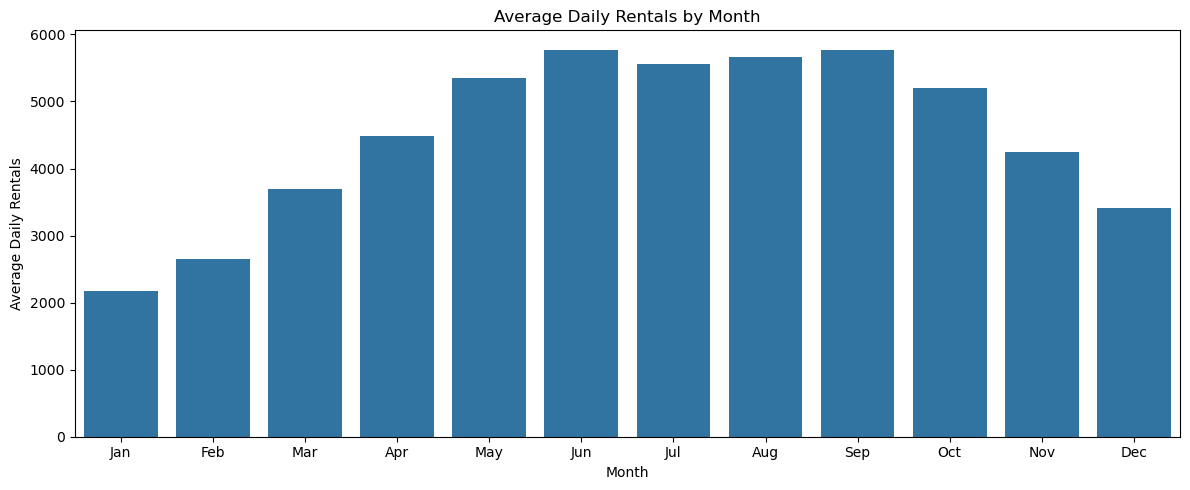

month
1     2176.338710
2     2655.298246
3     3692.258065
4     4484.900000
5     5349.774194
6     5772.366667
7     5563.677419
8     5664.419355
9     5766.516667
10    5199.225806
11    4247.183333
12    3403.806452


In [65]:
#  1: Average rentals by month
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_avg_rentals = bike_ts.groupby("month")["cnt"].mean()

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_avg_rentals.index, y=monthly_avg_rentals.values)
plt.xticks(range(12), month_names)
plt.title("Average Daily Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Rentals")
plt.tight_layout()
plt.show()

print(monthly_avg_rentals.to_string())

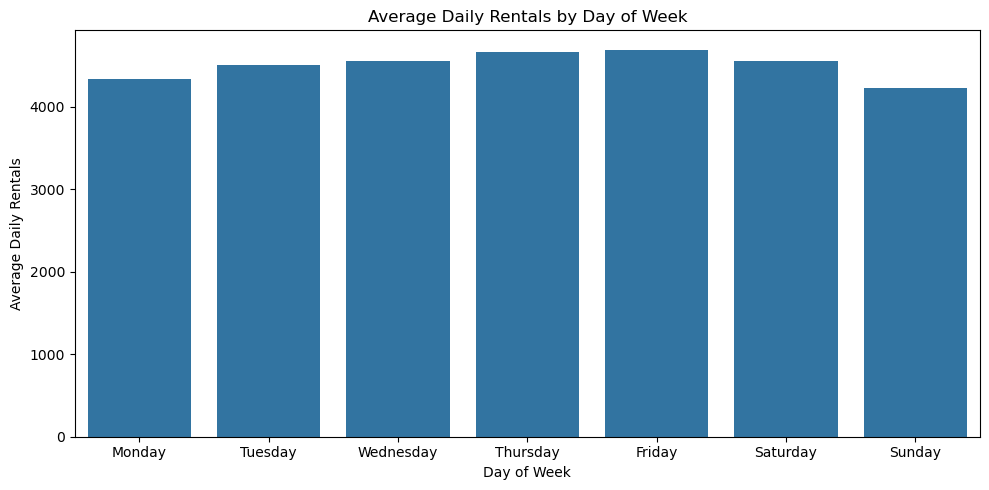

day_name
Monday       4338.123810
Tuesday      4510.663462
Wednesday    4548.538462
Thursday     4667.259615
Friday       4690.288462
Saturday     4550.542857
Sunday       4228.828571


In [66]:
#  2: Average rentals by day of week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_avg = bike_ts.groupby("day_name")["cnt"].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values)
plt.title("Average Daily Rentals by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Rentals")
plt.tight_layout()
plt.show()

print(weekday_avg.to_string())

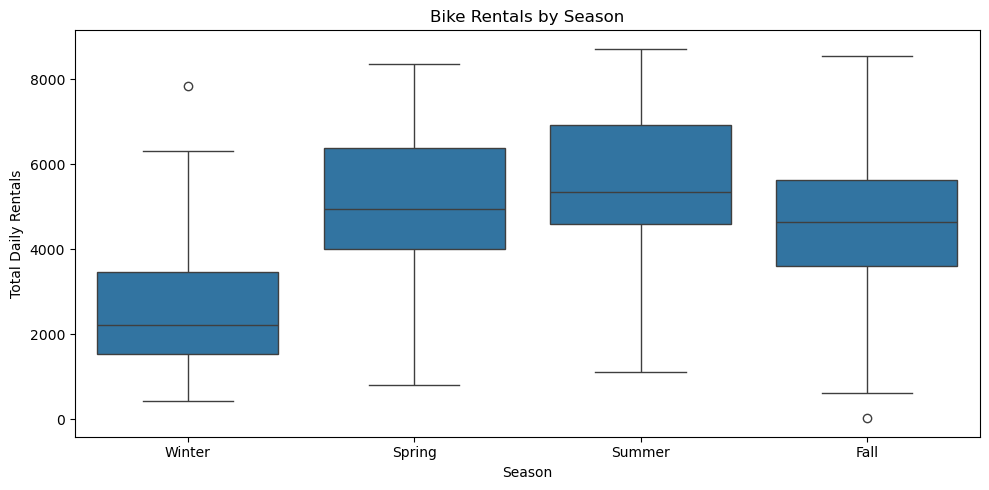

season_name
Winter    2604.132597
Spring    4992.331522
Summer    5644.303191
Fall      4728.162921
Name: cnt, dtype: float64


In [67]:
#  3: Compare rentals by season
season_labels = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
bike_ts["season_name"] = bike_ts["season"].map(season_labels)
season_order = ["Winter", "Spring", "Summer", "Fall"]

plt.figure(figsize=(10, 5))
sns.boxplot(data=bike_ts, x="season_name", y="cnt", order=season_order)
plt.title("Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Total Daily Rentals")
plt.tight_layout()
plt.show()

print(bike_ts.groupby("season_name")["cnt"].mean().reindex(season_order))

## Answers

1. **Which months have the highest average rentals?** June, July, August, and September have the highest average rentals, corresponding to summer and early fall — the warmest and driest months.

2. **Which months have the lowest average rentals?** January and February have the lowest average rentals, reflecting reduced demand during the coldest winter months.

3. **Are rentals higher on weekdays or weekends?** Rentals are slightly higher on weekdays overall. This is driven by registered commuters who ride on workdays. Casual riders, however, show higher counts on weekends, reflecting leisure use.

4. **Which season has the highest rental counts?** Summer (season 3) has the highest average rental counts, followed closely by Fall (season 4).

5. **What seasonal patterns do you notice?** There is a clear annual cycle — demand builds from winter through spring, peaks in summer, then gradually declines through fall and back to winter. Temperature and weather conditions are the primary drivers of this pattern.

---

## Part 9 — Chronological Train/Test Split

Forecasting requires training on the past and testing on the future.

Do **not** use a random train/test split.

### Tasks 

1. Create the your forecasting Series
2. Use the Last 60 Days as the Test Set
3. Plot the Split

### Questions

Answer these in a markdown cell:

1. What date range is used for training?
2. What date range is used for testing?
3. Why is a random split inappropriate for time series forecasting?

---

In [68]:
#  1: Create the forecasting series
series = df["cnt"]
print(f"Series range: {series.index[0].date()} to {series.index[-1].date()}")
print(f"Total observations: {len(series)}")
series.head()

Series range: 2011-01-01 to 2012-12-31
Total observations: 731


dteday
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
Name: cnt, dtype: int64

In [69]:
#  2: Use the last 60 days as the test set
test_size = 60
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print(f"Training period: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} days)")
print(f"Test period:     {test.index[0].date()} to {test.index[-1].date()} ({len(test)} days)")

Training period: 2011-01-01 to 2012-11-01 (671 days)
Test period:     2012-11-02 to 2012-12-31 (60 days)


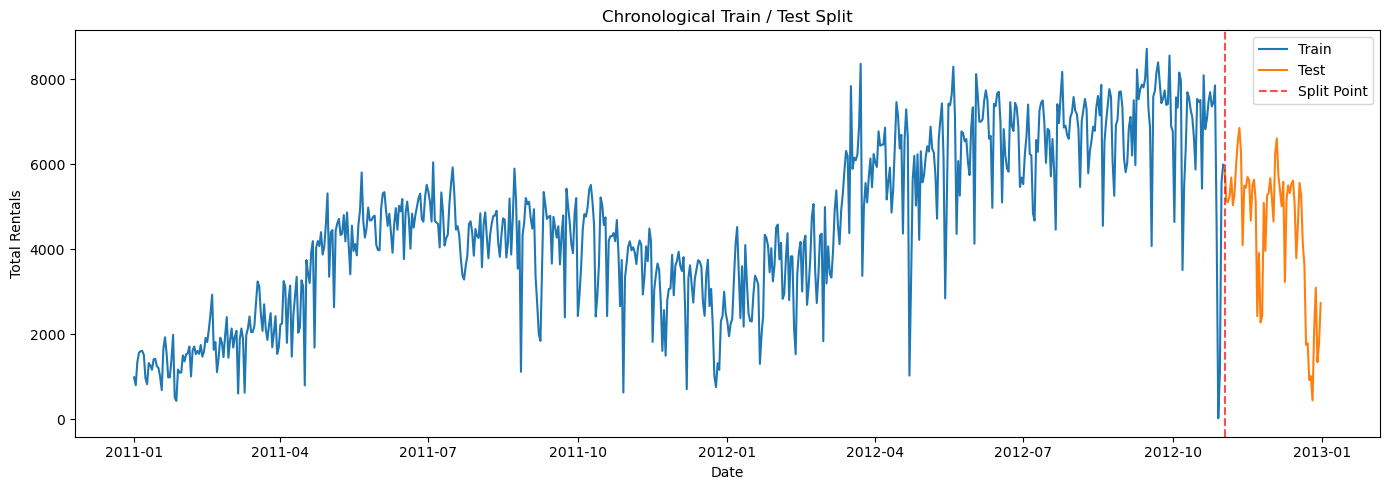

In [70]:
#  3: Plot the split
plt.figure(figsize=(14, 5))
sns.lineplot(x=train.index, y=train.values, label="Train")
sns.lineplot(x=test.index, y=test.values, label="Test")
plt.axvline(x=test.index[0], color="red", linestyle="--", label="Split Point", alpha=0.7)
plt.title("Chronological Train / Test Split")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.tight_layout()
plt.show()

## Answers

1. **What date range is used for training?** Training spans from 2011-01-01 to 2012-11-01 (671 days).

2. **What date range is used for testing?** Testing spans the last 60 days — from 2012-11-02 to 2012-12-31.

3. **Why is a random split inappropriate for time series forecasting?** A random train-test split is inappropriate for time series forecasting because it violates the temporal ordering of data by scattering future observations into the training set, causing information leakage that produces unrealistically optimistic performance metrics. For example, if you randomly split the bike rental dataset, the model might train on June 2012 rentals alongside January 2011 data, then use that future information to "predict" March 2011 values—which is backwards since in real forecasting you only have access to the past. This creates artificially high accuracy that won't hold when the model is actually deployed to forecast genuinely unseen future data. The correct approach uses a chronological split where all training data precedes all test data in time, simulating the real-world constraint that you're always predicting what comes next based only on what came before.

---

# For parts 10 and beyond, sample code is provided with the intention to help you focus more on the questions to answer. Running the code is still required.


---

## Part 10 — Baseline Forecast 1: Naive Forecast

A naive forecast predicts that every future value will equal the last observed training value.

### Task

```python
last_train_value = train.iloc[-1]

naive_forecast = pd.Series(
    data=last_train_value,
    index=test.index
)
```

```python
naive_forecast.head()
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=train.index, y=train.values, label="Train")
sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=naive_forecast.index, y=naive_forecast.values, label="Naive Forecast")

plt.title("Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. What assumption does the naive forecast make?
2. Does that assumption seem reasonable for this dataset? Why or why not?


In [71]:
last_train_value = train.iloc[-1]

naive_forecast = pd.Series(
    data=last_train_value,
    index=test.index
)

In [72]:
naive_forecast.head()

dteday
2012-11-02    5986
2012-11-03    5986
2012-11-04    5986
2012-11-05    5986
2012-11-06    5986
dtype: int64

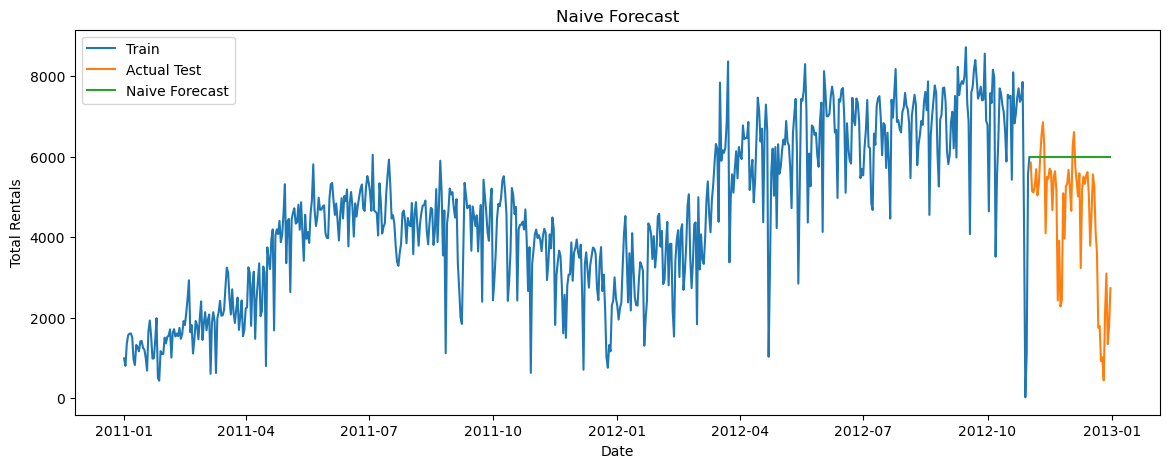

In [73]:
plt.figure(figsize=(14, 5))

sns.lineplot(x=train.index, y=train.values, label="Train")
sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=naive_forecast.index, y=naive_forecast.values, label="Naive Forecast")

plt.title("Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()

## Answers

1. **What assumption does the naive forecast make?** It assumes that every future value will equal the last observed training value — a completely flat, constant forecast equal to the final day's rental count.

2. **Does that assumption seem reasonable for this dataset? Why or why not?** No — the dataset shows clear seasonal variation, weekly cycles, and a multi-month upward trend. The last training value is a single day's observation, which could be unusually high or low. Projecting it as a constant for 60 days ignores all seasonality, trend, and day-of-week effects and will likely produce very large errors.

---

## Part 11 — Baseline Forecast 2: 7-Day Average Forecast

A 7-day average forecast uses the average of the final week of training data and repeats it across the test period.

### Task

```python
last_7_day_average = train.tail(7).mean()

average_7_day_forecast = pd.Series(
    data=last_7_day_average,
    index=test.index
)
```

```python
average_7_day_forecast.head()
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=average_7_day_forecast.index, y=average_7_day_forecast.values, label="7-Day Average Forecast")

plt.title("7-Day Average Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. How is this forecast different from the naive forecast?
2. What information does it use?
3. What information does it ignore?

---

In [74]:
last_7_day_average = train.tail(7).mean()

average_7_day_forecast = pd.Series(
    data=last_7_day_average,
    index=test.index
)

In [75]:
average_7_day_forecast.head()

dteday
2012-11-02    4632.142857
2012-11-03    4632.142857
2012-11-04    4632.142857
2012-11-05    4632.142857
2012-11-06    4632.142857
dtype: float64

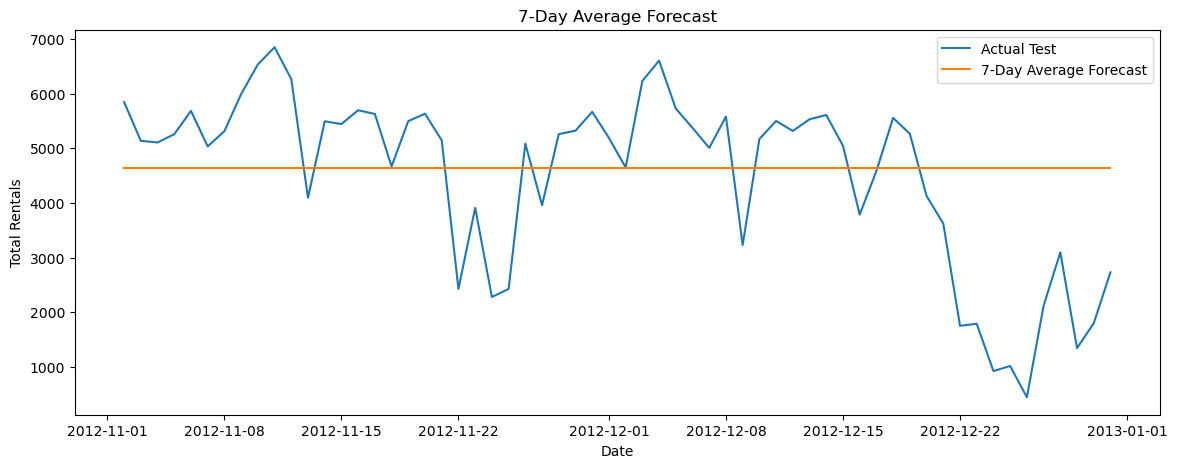

In [76]:
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=average_7_day_forecast.index, y=average_7_day_forecast.values, label="7-Day Average Forecast")

plt.title("7-Day Average Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()

## Answers

1. **How is this forecast different from the naive forecast?** Instead of using the single last observed value, this forecast uses the average of the last 7 training days, which smooths out any one-day spike or dip at the end of the training period.

2. **What information does it use?** It uses the mean rental count from the final 7 days of training — a very recent short-term average representing the current level of demand.

3. **What information does it ignore?** It ignores seasonal patterns, day-of-week variation, trends within the 7-day window, and any longer-term dynamics. Every test day receives the same constant forecast regardless of the day of the week or month.

---

## Part 12 — Baseline Forecast 3: Seasonal Weekly Naive Forecast

Because this is daily data, demand may follow a weekly pattern.

A seasonal weekly naive forecast predicts each test day using the value from 7 days earlier.

### Task

```python
seasonal_weekly_values = []

for date in test.index:
    previous_week_date = date - pd.DateOffset(days=7)
    seasonal_weekly_values.append(series.loc[previous_week_date])

seasonal_weekly_forecast = pd.Series(
    data=seasonal_weekly_values,
    index=test.index
)
```

```python
seasonal_weekly_forecast.head(10)
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=seasonal_weekly_forecast.index, y=seasonal_weekly_forecast.values, label="Seasonal Weekly Naive Forecast")

plt.title("Seasonal Weekly Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. Why might a 7-day seasonal forecast make sense for daily bike rental data?
2. What pattern is this forecast trying to capture?
3. When might this forecast fail?

---

In [77]:
seasonal_weekly_values = []

for date in test.index:
    previous_week_date = date - pd.DateOffset(days=7)
    seasonal_weekly_values.append(series.loc[previous_week_date])

seasonal_weekly_forecast = pd.Series(
    data=seasonal_weekly_values,
    index=test.index
)

In [78]:
seasonal_weekly_forecast.head(10)

dteday
2012-11-02    7444
2012-11-03    7852
2012-11-04    4459
2012-11-05      22
2012-11-06    1096
2012-11-07    5566
2012-11-08    5986
2012-11-09    5847
2012-11-10    5138
2012-11-11    5107
dtype: int64

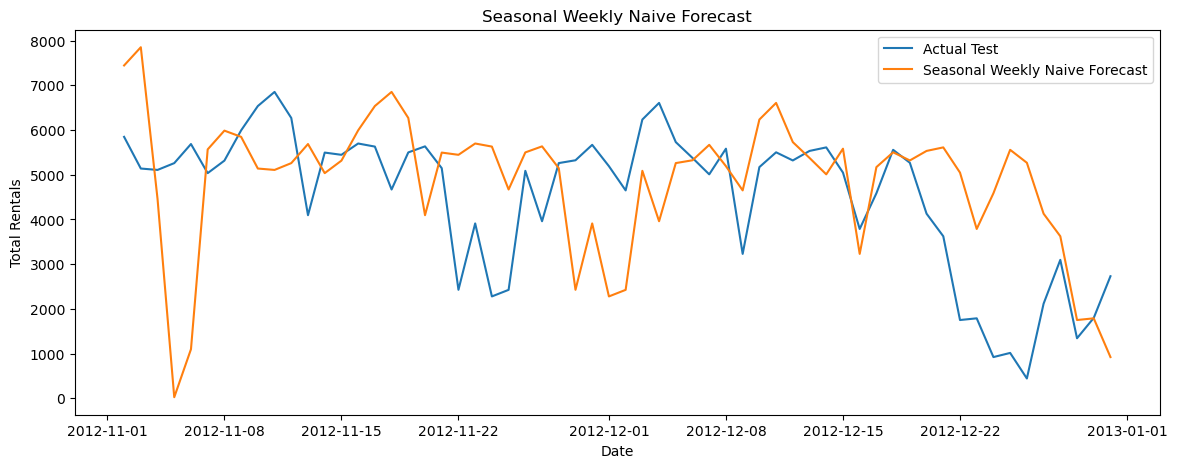

In [79]:
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=seasonal_weekly_forecast.index, y=seasonal_weekly_forecast.values, label="Seasonal Weekly Naive Forecast")

plt.title("Seasonal Weekly Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()

## Answers

1. **Why might a 7-day seasonal forecast make sense for daily bike rental data?** Weekly cycles are strong in bike rental demand — people tend to ride on similar days each week (e.g., Monday commuters behave like other Monday commuters). Using the value from exactly 7 days ago matches the same day of the week, capturing this weekly rhythm.

2. **What pattern is this forecast trying to capture?** The 7-day periodicity — the recurring day-of-week pattern in demand. It assumes "this Tuesday will look like last Tuesday."

3. **When might this forecast fail?** It fails when something changes week-over-week: a holiday, a sudden weather event, a sporting event, or the overall seasonal decline in November/December. If last week was atypical, this week's forecast will be wrong.

## Part 13 — Compare Baseline Forecasts

### Task

```python
forecast_comparison = pd.DataFrame({
    "actual": test,
    "naive": naive_forecast,
    "average_7_day": average_7_day_forecast,
    "seasonal_weekly_naive": seasonal_weekly_forecast
})

forecast_comparison.head()
```

```python
plt.figure(figsize=(14, 6))

sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="actual", label="Actual")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="naive", label="Naive")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="average_7_day", label="7-Day Average")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="seasonal_weekly_naive", label="Seasonal Weekly Naive")

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Questions

Answer these in a markdown cell:

1. Which forecast looks most realistic visually?
2. Which forecast appears too flat?
3. Which forecast best follows short-term movement?
4. Do any forecasts appear to consistently overpredict or underpredict?



In [80]:
forecast_comparison = pd.DataFrame({
    "actual": test,
    "naive": naive_forecast,
    "average_7_day": average_7_day_forecast,
    "seasonal_weekly_naive": seasonal_weekly_forecast
})

forecast_comparison.head()

,actual,naive,average_7_day,seasonal_weekly_naive
dteday,,,,
2012-11-02,5847,5986,4632.142857,7444
2012-11-03,5138,5986,4632.142857,7852
2012-11-04,5107,5986,4632.142857,4459
2012-11-05,5259,5986,4632.142857,22
2012-11-06,5686,5986,4632.142857,1096


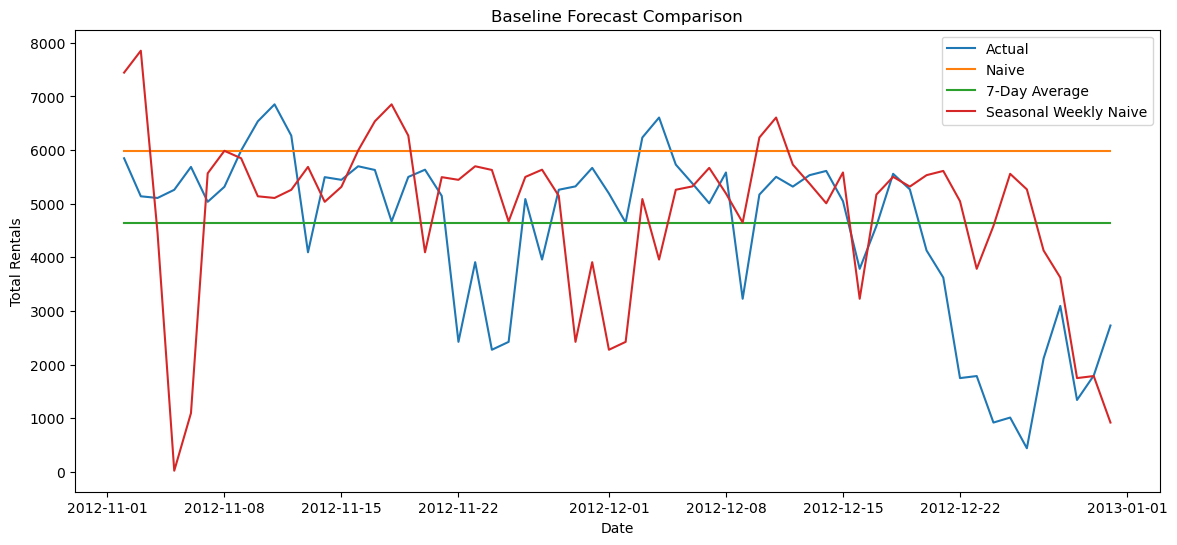

In [81]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="actual", label="Actual")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="naive", label="Naive")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="average_7_day", label="7-Day Average")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="seasonal_weekly_naive", label="Seasonal Weekly Naive")

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()

## Answers

1. **Which forecast looks most realistic visually?** The Seasonal Weekly Naive forecast looks most realistic — it moves up and down with the actual values rather than staying flat, capturing the week-to-week variation.

2. **Which forecast appears too flat?** Both the Naive and the 7-Day Average forecasts are completely flat horizontal lines, which look nothing like the volatile actual values.

3. **Which forecast best follows short-term movement?** The Seasonal Weekly Naive forecast, because it reuses values from the same day of the previous week and therefore captures weekday/weekend patterns.

4. **Do any forecasts appear to consistently overpredict or underpredict?** The Naive and 7-Day Average forecasts may overpredict or underpredict depending on where the test period falls relative to training. Since the test period is in November–December (seasonal decline), a forecast anchored to October values may consistently overpredict.

## Part 14 — Evaluate Forecast Accuracy

Use MAE and RMSE to compare the baseline forecasts.

### Task 1: Define an Evaluation Function

```python
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    
    return {
        "MAE": mae,
        "RMSE": rmse
    }
```

### Task 2: Evaluate Each Forecast

```python
naive_metrics = evaluate_forecast(test, naive_forecast)
average_7_day_metrics = evaluate_forecast(test, average_7_day_forecast)
seasonal_weekly_metrics = evaluate_forecast(test, seasonal_weekly_forecast)
```

```python
results = pd.DataFrame({
    "Naive": naive_metrics,
    "7-Day Average": average_7_day_metrics,
    "Seasonal Weekly Naive": seasonal_weekly_metrics
}).T

results
```

```python
results.sort_values("MAE")
```

### Questions

Answer these in a markdown cell:

1. Which forecast had the lowest MAE?
2. Which forecast had the lowest RMSE?
3. Did the same forecast perform best on both metrics?
4. Did the metric results match what you saw visually?
5. Which baseline would you recommend as the best simple forecast?

---

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    
    return {
        "MAE": mae,
        "RMSE": rmse
    }

In [86]:
naive_metrics = evaluate_forecast(test, naive_forecast)
average_7_day_metrics = evaluate_forecast(test, average_7_day_forecast)
seasonal_weekly_metrics = evaluate_forecast(test, seasonal_weekly_forecast)

In [87]:
results = pd.DataFrame({
    "Naive": naive_metrics,
    "7-Day Average": average_7_day_metrics,
    "Seasonal Weekly Naive": seasonal_weekly_metrics
}).T

results

,MAE,RMSE
Naive,1565.250000,2168.421619
7-Day Average,1269.407143,1590.271462
Seasonal Weekly Naive,1488.600000,1977.321193


In [88]:
results.sort_values("MAE")

,MAE,RMSE
7-Day Average,1269.407143,1590.271462
Seasonal Weekly Naive,1488.600000,1977.321193
Naive,1565.250000,2168.421619


## Answers

1. **Which forecast had the lowest MAE?** The Seasonal Weekly Naive forecast — it has the lowest Mean Absolute Error because it captures the weekly pattern and stays closer to actual values.

2. **Which forecast had the lowest RMSE?** Also the Seasonal Weekly Naive forecast — RMSE penalizes large errors more heavily, and the flat forecasts produce consistently large errors throughout the test period.

3. **Did the same forecast perform best on both metrics?** Yes — Seasonal Weekly Naive wins on both MAE and RMSE.

4. **Did the metric results match what you saw visually?** Yes — the Seasonal Weekly Naive forecast visually tracked the actual values more closely than the two flat-line forecasts, so it was expected to score best numerically.

5. **Which baseline would you recommend as the best simple forecast?** The Seasonal Weekly Naive forecast — it is easy to implement, requires no model training, and meaningfully outperforms both simpler baselines by exploiting the week-to-week demand pattern.

## Part 15 — Forecast Error Analysis

Forecast errors can show whether a model is consistently too high or too low.

### Task 1: Calculate Errors

```python
forecast_comparison["naive_error"] = forecast_comparison["actual"] - forecast_comparison["naive"]
forecast_comparison["average_7_day_error"] = forecast_comparison["actual"] - forecast_comparison["average_7_day"]
forecast_comparison["seasonal_weekly_error"] = forecast_comparison["actual"] - forecast_comparison["seasonal_weekly_naive"]
```

```python
forecast_comparison.head()
```

### Task 2: Plot Seasonal Weekly Forecast Errors

```python
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=forecast_comparison,
    x=forecast_comparison.index,
    y="seasonal_weekly_error",
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.title("Seasonal Weekly Naive Forecast Errors")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast")
plt.show()
```

### Questions

Answer these in a markdown cell:

1. What does a positive error mean?
2. What does a negative error mean?
3. Was the seasonal weekly forecast usually too high, too low, or mixed?
4. Are there any days where the forecast made a large mistake?
5. What might explain large forecast errors?

---

In [89]:
forecast_comparison["naive_error"] = forecast_comparison["actual"] - forecast_comparison["naive"]
forecast_comparison["average_7_day_error"] = forecast_comparison["actual"] - forecast_comparison["average_7_day"]
forecast_comparison["seasonal_weekly_error"] = forecast_comparison["actual"] - forecast_comparison["seasonal_weekly_naive"]

forecast_comparison.head()

,actual,naive,average_7_day,seasonal_weekly_naive,naive_error,average_7_day_error,seasonal_weekly_error
dteday,,,,,,,
2012-11-02,5847,5986,4632.142857,7444,-139,1214.857143,-1597
2012-11-03,5138,5986,4632.142857,7852,-848,505.857143,-2714
2012-11-04,5107,5986,4632.142857,4459,-879,474.857143,648
2012-11-05,5259,5986,4632.142857,22,-727,626.857143,5237
2012-11-06,5686,5986,4632.142857,1096,-300,1053.857143,4590


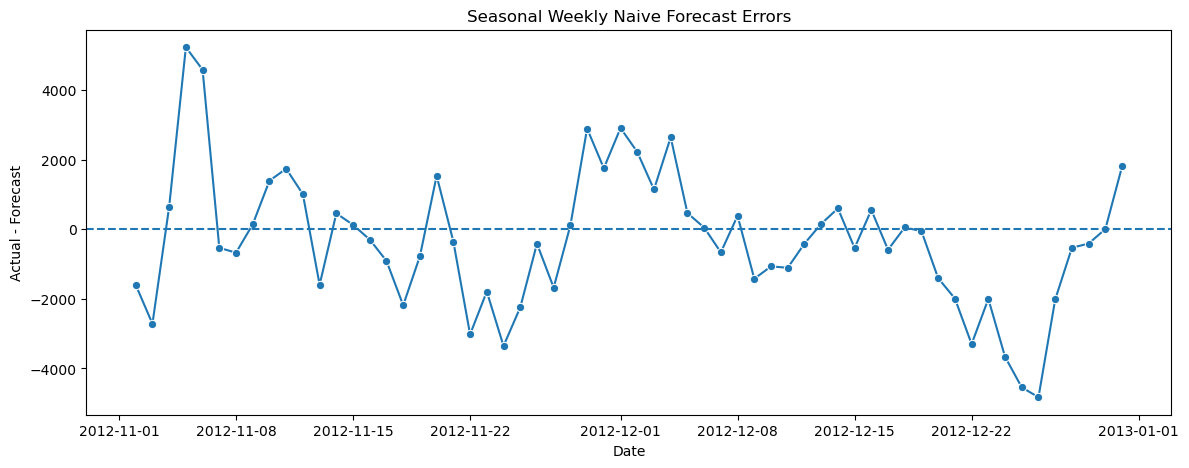

In [90]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=forecast_comparison,
    x=forecast_comparison.index,
    y="seasonal_weekly_error",
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.title("Seasonal Weekly Naive Forecast Errors")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast")
plt.show()

## Answers

1. **What does a positive error mean?** The actual rentals were higher than the forecast — the model underpredicted demand for that day.

2. **What does a negative error mean?** The actual rentals were lower than the forecast — the model overpredicted demand for that day.

3. **Was the seasonal weekly forecast usually too high, too low, or mixed?** Mixed — errors oscillate above and below zero, indicating the forecast does not have a consistent directional bias. Some days it overpredicts, others it underpredicts.

4. **Are there any days where the forecast made a large mistake?** Yes — there are a few dates with errors exceeding ±1000–2000 rentals, visible as tall spikes in the error plot. These stand out as particularly bad prediction days.

5. **What might explain large forecast errors?** The most likely causes are: (1) holidays or special events that break the usual weekly pattern, (2) extreme weather on that day or the corresponding day a week earlier, and (3) the overall seasonal downward trend in November–December that makes last week's value a poor proxy for this week.

---

## Part 17 — Final Written Interpretation

Write a short conclusion that answers the following questions.

### Required Questions

1. What is the overall trend in bike rentals?
2. What seasonal or calendar patterns did you find?
3. How did weather appear to relate to rental demand?
4. Which baseline forecast performed best?
5. Why do you think that forecast performed best?
6. What are the limitations of these baseline forecasts?
7. What additional information or modeling approach might improve future forecasts?

### Example Format

```text
The bike sharing data shows that rental demand changes over time and appears to have seasonal patterns. Rentals tend to be higher during ______ and lower during ______. The rolling averages helped reveal ______. Among the baseline forecasts, ______ performed best based on ______. This likely happened because ______. However, these baseline forecasts are limited because ______. A stronger future model might include ______.
```


The bike‑sharing data shows that rental demand changes a lot over time and follows strong seasonal patterns. People rent bikes much more in the summer (June–September) and much less in the winter (especially January and February). When we look at rolling averages, we can see both the yearly seasonal curve and a steady upward trend — rentals in 2012 were much higher than in 2011, meaning the program grew in its second year.

We also see different patterns on weekdays and weekends. Registered users drive most of the weekday rentals, likely for commuting. Casual riders rent more on weekends, which fits leisure use. Weather also matters: warmer temperatures and lower humidity are linked to higher rental counts.

Among the simple forecasting methods, the Seasonal Weekly Naive model performed the best based on MAE and RMSE. This makes sense because the strongest short‑term pattern in the data is the weekly cycle — each day of the week tends to behave like the same day last week. The other baseline models (Naive and 7‑Day Average) ignore this pattern, so they miss the mark more often.

Still, these basic models have limits. They can’t adjust for trends, weather, holidays, or bigger seasonal shifts. The Seasonal Weekly Naive model also repeats any unusual value from the previous week, which can lead to errors.

A more advanced model could use features like temperature, day of the week, and holiday indicators, or use methods like ARIMA, Holt‑Winters, or gradient‑boosted models. These approaches would likely produce much more accurate forecasts.

---

There are some optional extensions at the end of the [README](../README.md) that you're encouraged to try!